In [1]:
import tensorflow as tf
from tensorflow.keras import layers

In [2]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.2)
])

In [6]:
model = tf.keras.Sequential([
    layers.InputLayer(shape=(32,32,1)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(10,activation='softmax')
])

In [7]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        72,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,330 (282.54 KB)

 Trainable params: 72,330 (282.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def load_and_preprocess(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image,channels=3)
    image = tf.image.resize(image, [180,180])
    return image

In [10]:
image = load_and_preprocess("../Digital-Image-Processing-Assignments/Dollar.jpg")

In [11]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [12.133347..255.0].


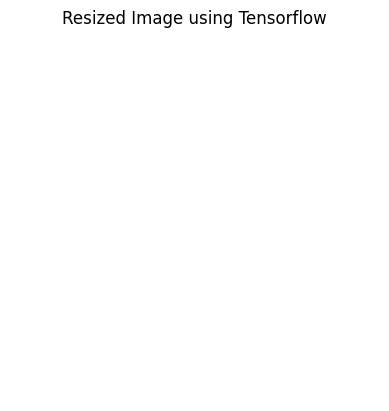

In [14]:
plt.imshow(image,cmap='gray')
plt.axis('off')
plt.title("Resized Image using Tensorflow")
plt.show()

In [15]:
def augment(image,label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image,max_delta=0.2)
    image = tf.image.random_contrast(image,lower=0.8,upper=1.2)
    image = tf.clip_by_value(image,0.0,255.0)
    return image, label

In [16]:
# dataset = tf.data.Dataset.from_tensor_slices((image_paths,labels))
# dataset = dataset.map(augment,num_parallel_calls=tf.data.AUTOTUNE)
# dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)